<a href="https://colab.research.google.com/github/muhammadhasbiashiddiqi/PCVK_Genap_2026/blob/main/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

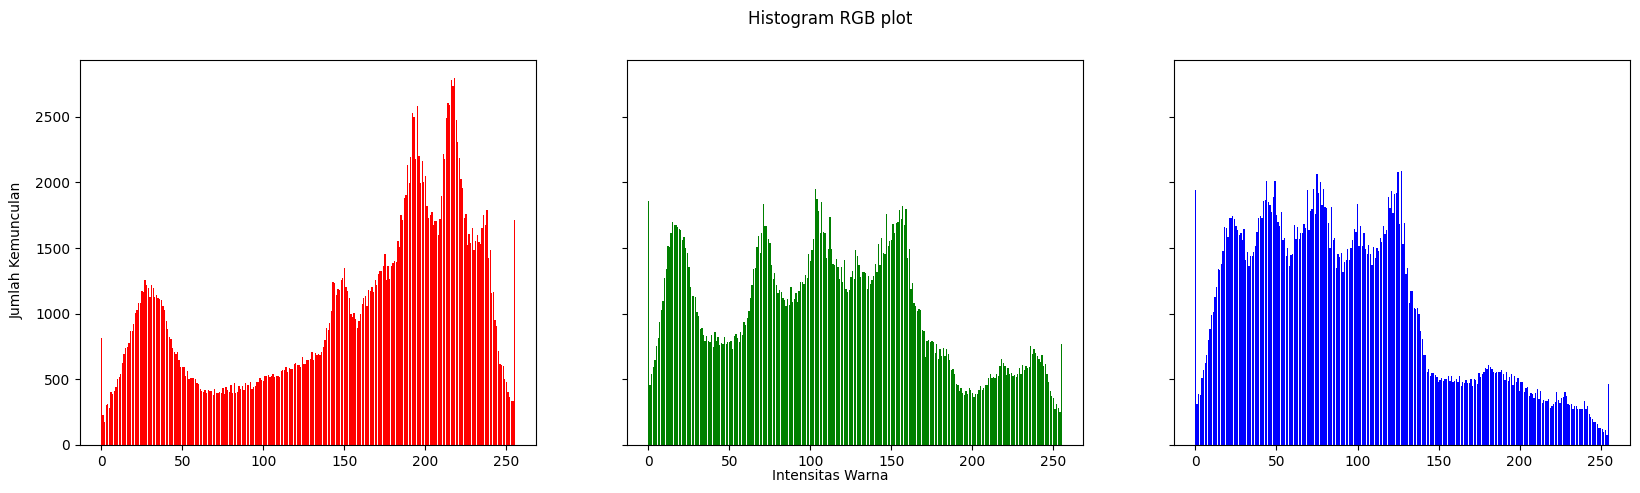

In [8]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lena.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [11]:
import os
import cv2 as cv
import numpy as np
CONTOH = '/content/drive/MyDrive/PCVK/Gambar'
BASE = '/content/drive/MyDrive/PCVK/Gambar'

def verifikasi_histogram(img_path):
  gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

  if gray is None:
    print(f'Gagal membaca citra dari path: {img_path}')
    return
  h_manual = np.zeros(256, dtype=np.int64)
  for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):
      h_manual[gray[y, x]] += 1
  h_numpy, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
  h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
  diff_manual_np = np.max(np.abs(h_manual - h_numpy))
  diff_manual_cv = np.max(np.abs(h_manual - h_cv))
  diff_np_cv = np.max(np.abs(h_numpy - h_cv))

  # hasil
  print(f'=== VERIFIKASI HISTOGRAM: {os.path.basename(img_path)} ===')
  print(f'Selisih Maksimum Manual vs NumPy  : {diff_manual_np}')
  print(f'Selisih Maksimum Manual vs OpenCV : {diff_manual_cv}')
  print(f'Selisih Maksimum NumPy vs OpenCV  : {diff_np_cv}')

  if diff_manual_np == 0 and diff_manual_cv == 0 and diff_np_cv == 0:
    print('STATUS: HASIL SAMA PERSIS (Selisih = 0)\n')
  else:
    print('STATUS: TERDAPAT PERBEDAAN\n')


# lena
verifikasi_histogram(CONTOH + '/Lena.jpeg')

# ktm
verifikasi_histogram(BASE + '/ktm.png')

=== VERIFIKASI HISTOGRAM: Lena.jpeg ===
Selisih Maksimum Manual vs NumPy  : 0
Selisih Maksimum Manual vs OpenCV : 0.0
Selisih Maksimum NumPy vs OpenCV  : 0.0
STATUS: HASIL SAMA PERSIS (Selisih = 0)

=== VERIFIKASI HISTOGRAM: ktm.png ===
Selisih Maksimum Manual vs NumPy  : 0
Selisih Maksimum Manual vs OpenCV : 0.0
Selisih Maksimum NumPy vs OpenCV  : 0.0
STATUS: HASIL SAMA PERSIS (Selisih = 0)



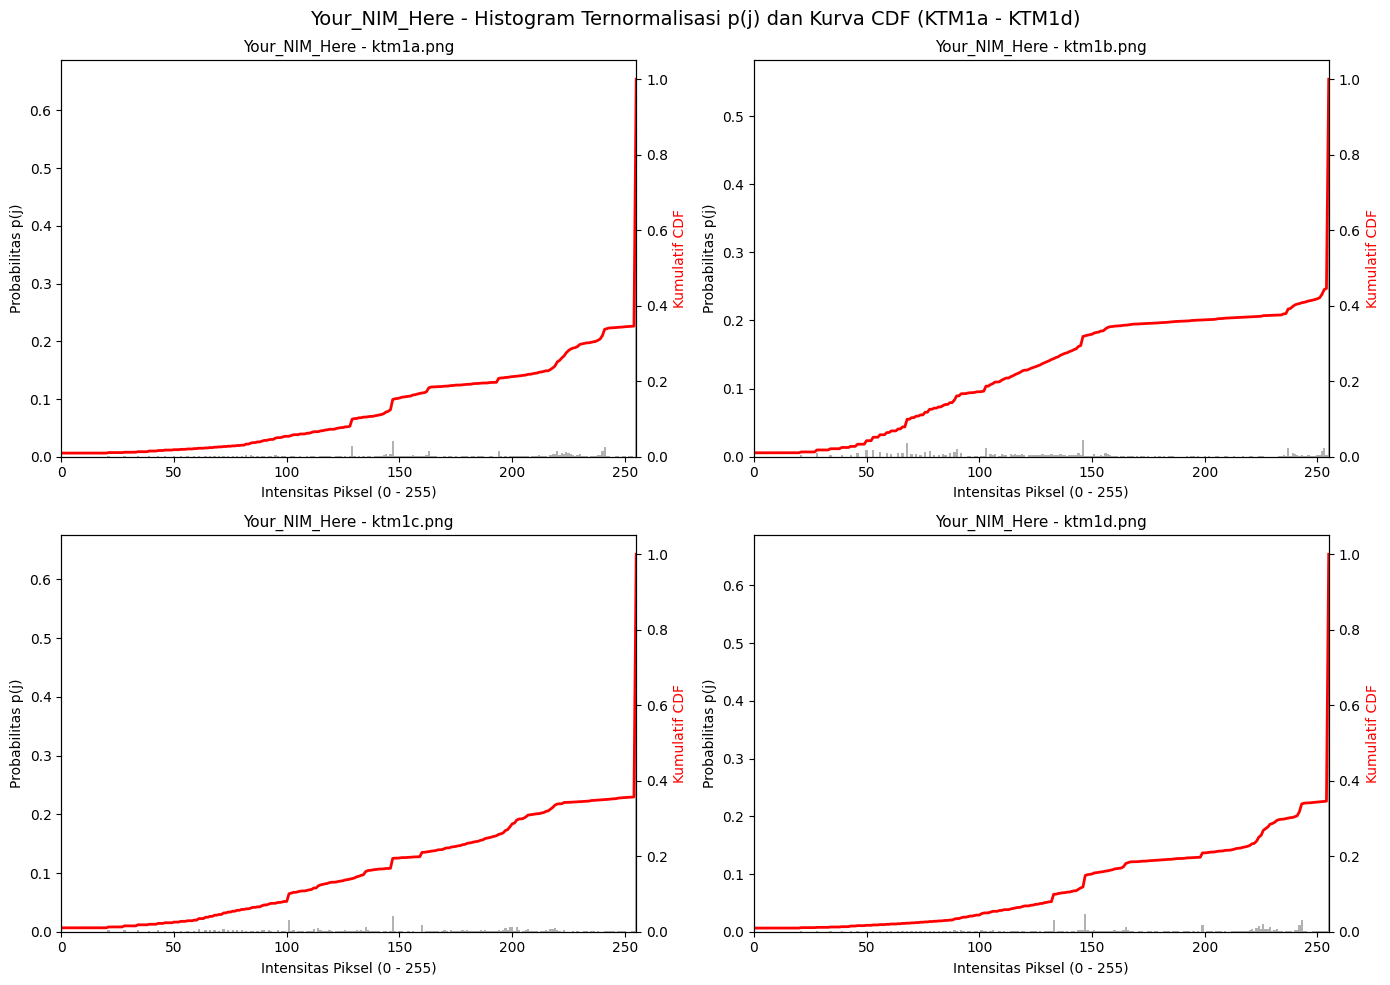

In [20]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
NIM = 'Your_NIM_Here'
ktm_files = ['ktm1a.png', 'ktm1b.png', 'ktm1c.png', 'ktm1d.png']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'{NIM} - Histogram Ternormalisasi p(j) dan Kurva CDF (KTM1a - KTM1d)',
    fontsize=14,
)
for idx, fname in enumerate(ktm_files):
  row, col = idx // 2, idx % 2
  img_path = BASE + '/' + fname
  gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

  if gray is None:
    print(f'Gagal membaca citra dari path: {img_path}. Pastikan file ada dan path benar.')
    continue
  h, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
  p = h / gray.size
  cdf = np.cumsum(p)

  ax = axs[row, col]
  ax.bar(
      range(256),
      p,
      color='gray',
      alpha=0.6,
      width=1.0,
      label='p(j) Normalisasi',
  )
  ax.set_title(f'{NIM} - {fname}', fontsize=11)
  ax.set_xlabel('Intensitas Piksel (0 - 255)')
  ax.set_ylabel('Probabilitas p(j)', color='black')
  ax.set_xlim([0, 255])
  ax2 = ax.twinx()
  ax2.plot(range(256), cdf, color='red', linewidth=2, label='CDF')
  ax2.set_ylabel('Kumulatif CDF', color='red')
  ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

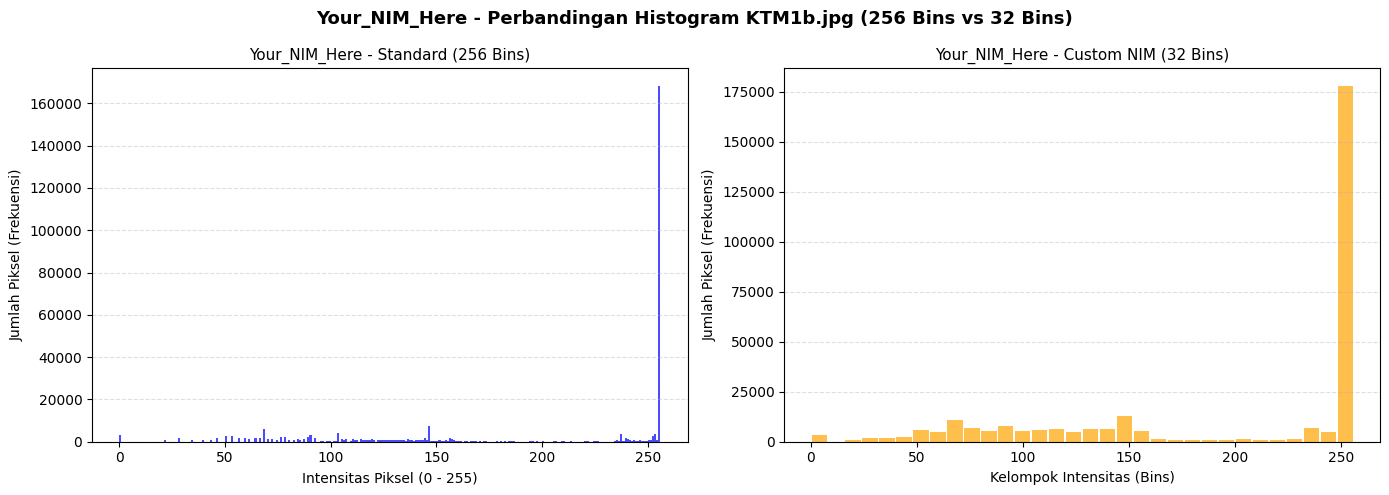

In [22]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
PARAM = {'bins': 32}

img_path = BASE + '/ktm1b.png'
gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
num_bins = PARAM['bins']
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{NIM} - Perbandingan Histogram KTM1b.jpg (256 Bins vs {num_bins} Bins)",
    fontsize=13,
    fontweight='bold',
)

axs[0].hist(gray.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axs[0].set_title(f'{NIM} - Standard (256 Bins)', fontsize=11)
axs[0].set_xlabel('Intensitas Piksel (0 - 255)')
axs[0].set_ylabel('Jumlah Piksel (Frekuensi)')
axs[0].grid(axis='y', linestyle='--', alpha=0.4)

axs[1].hist(
    gray.ravel(),
    bins=num_bins,
    range=(0, 256),
    color='orange',
    alpha=0.7,
    rwidth=0.9,
)
axs[1].set_title(f"{NIM} - Custom NIM ({num_bins} Bins)", fontsize=11)
axs[1].set_xlabel('Kelompok Intensitas (Bins)')
axs[1].set_ylabel('Jumlah Piksel (Frekuensi)')
axs[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

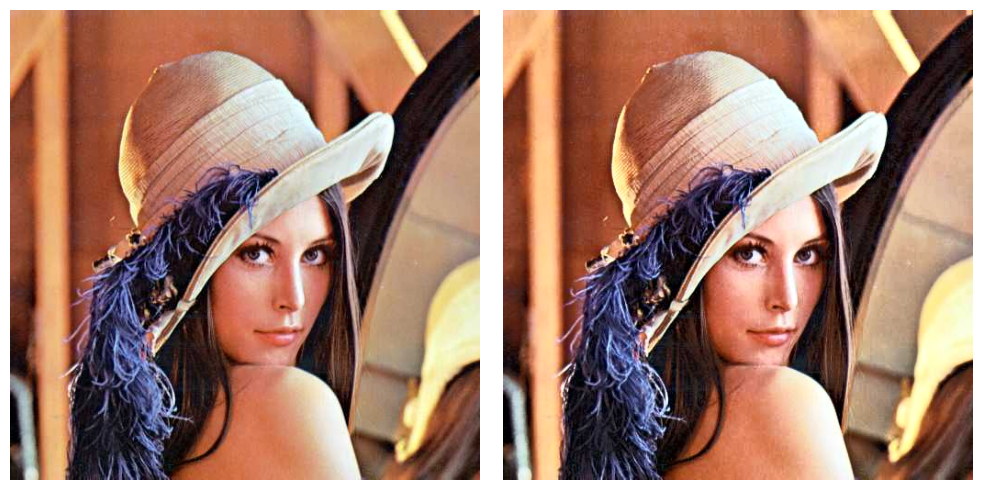

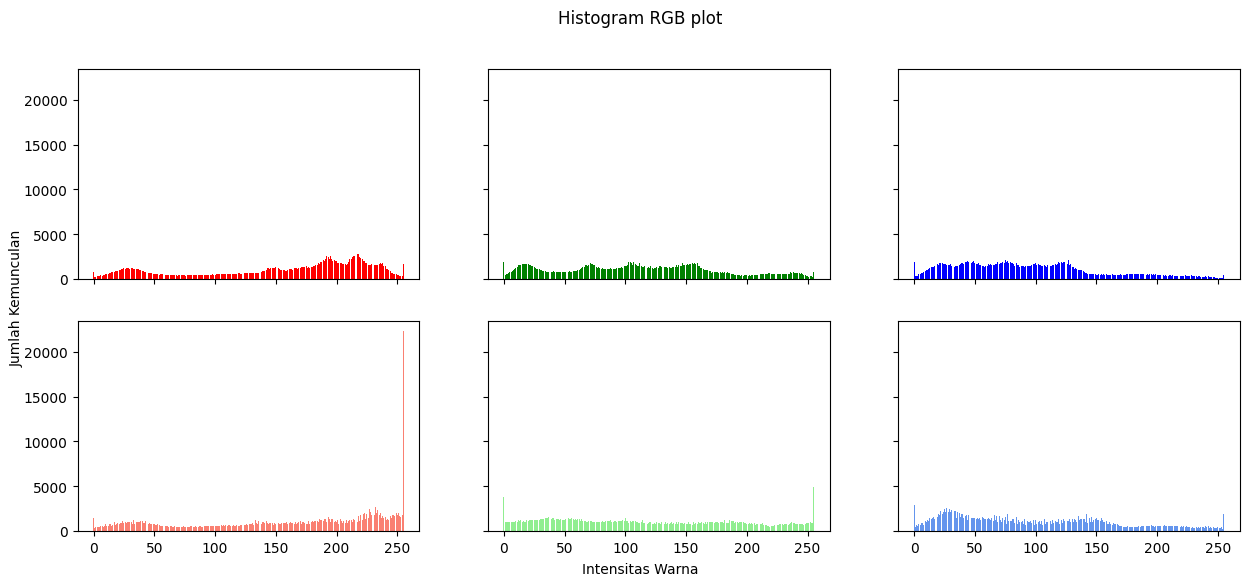

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img_low = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lena.jpeg')
img_low = cv.cvtColor(img_low, cv.COLOR_BGR2RGB)
ycrcb = cv.cvtColor(img_low, cv.COLOR_RGB2YCrCb)
ycrcb[:, :, 0] = cv.equalizeHist(ycrcb[:, :, 0])
img_enhanced = cv.cvtColor(ycrcb, cv.COLOR_YCrCb2RGB)

fig_img, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_low)
ax1.axis('off')

ax2.imshow(img_enhanced)
ax2.axis('off')

plt.tight_layout()
plt.show()

def calc_rgb_hist(image):
    h, w, _ = image.shape
    r_hist = [0] * 256
    g_hist = [0] * 256
    b_hist = [0] * 256

    for y in range(h):
        for x in range(w):
            r_hist[image[y][x][0]] += 1
            g_hist[image[y][x][1]] += 1
            b_hist[image[y][x][2]] += 1

    return r_hist, g_hist, b_hist

r_low, g_low, b_low = calc_rgb_hist(img_low)
r_enh, g_enh, b_enh = calc_rgb_hist(img_enhanced)

names = np.arange(256)

fig_hist, axs = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)
fig_hist.suptitle('Histogram RGB plot')

axs[0, 0].bar(names, r_low, color='red')
axs[0, 1].bar(names, g_low, color='green')
axs[0, 2].bar(names, b_low, color='blue')

axs[1, 0].bar(names, r_enh, color='salmon')
axs[1, 1].bar(names, g_enh, color='lightgreen')
axs[1, 2].bar(names, b_enh, color='cornflowerblue')

# Label Sumbu
fig_hist.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig_hist.text(0.5, 0.04, 'Intensitas Warna', ha='center')

plt.show()

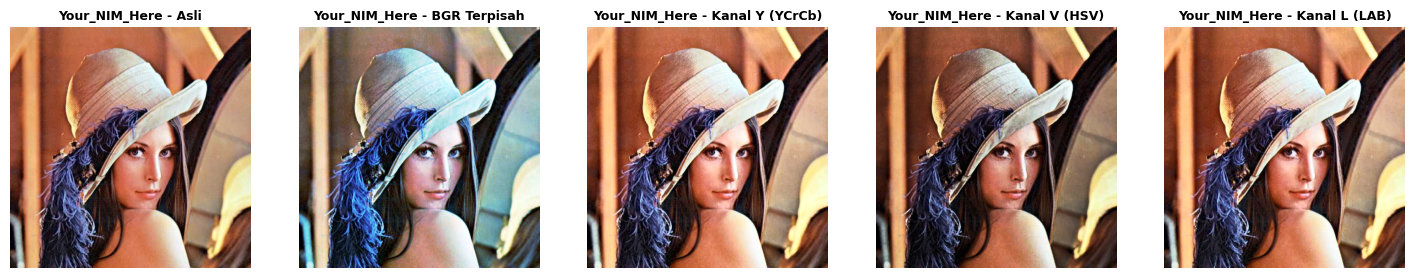

=== Tabel Pergeseran Hue & Rerata Kecerahan (Lena.jpeg) ===
Metode Ekualisasi         | Pergeseran Hue (°)   | Rerata Kecerahan  
----------------------------------------------------------------------
Asli                      | 0.00                 | 122.24            
BGR Terpisah              | 53.03                | 127.37            
Kanal Y (YCrCb)           | 0.40                 | 127.90            
Kanal V (HSV)             | 0.87                 | 100.55            
Kanal L (LAB)             | 1.65                 | 122.72            




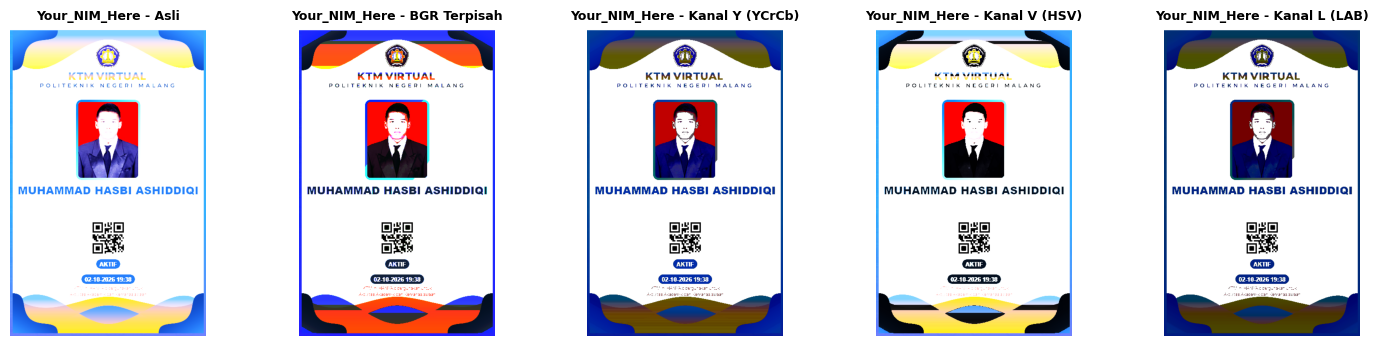

=== Tabel Pergeseran Hue & Rerata Kecerahan (ktm1d.pngg) ===
Metode Ekualisasi         | Pergeseran Hue (°)   | Rerata Kecerahan  
----------------------------------------------------------------------
Asli                      | 0.00                 | 220.30            
BGR Terpisah              | 10.00                | 190.68            
Kanal Y (YCrCb)           | 1.47                 | 185.12            
Kanal V (HSV)             | 0.55                 | 206.82            
Kanal L (LAB)             | 1.95                 | 181.34            




In [28]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
def geser_hue(asli, hasil):
  """Menghitung rerata pergeseran nilai Hue (dalam derajat 0-180)."""
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)
  return d.mean()
def evaluasi_ekualisasi_warna(img_path, title):
  bgr = cv.imread(img_path)
  if bgr is None:
    print(f'Gagal membaca citra: {img_path}')
    return
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_bgr = cv.merge(kanal)

  ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
  hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
  h, s, v = cv.split(hsv)
  he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
  lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
  l, a, b = cv.split(lab)
  he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

  judul = ['Asli', 'BGR Terpisah', 'Kanal Y (YCrCb)', 'Kanal V (HSV)', 'Kanal L (LAB)']
  citra = [bgr, he_bgr, he_y, he_v, he_l]
  plt.figure(figsize=(18, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - {t}', fontsize=9, fontweight='bold')
    plt.axis('off')
  plt.show()
  print(f'=== Tabel Pergeseran Hue & Rerata Kecerahan ({title}) ===')
  print(f"{'Metode Ekualisasi':<25} | {'Pergeseran Hue (°)':<20} | {'Rerata Kecerahan':<18}")
  print('-' * 70)
  for t, c in zip(judul, citra):
    hue_shift = geser_hue(bgr, c) * 2
    brightness = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print(f'{t:<25} | {hue_shift:<20.2f} | {brightness:<18.2f}')
  print('\n')
evaluasi_ekualisasi_warna(CONTOH + '/Lena.jpeg', 'Lena.jpeg')
evaluasi_ekualisasi_warna(BASE + '/ktm1d.png', 'ktm1d.pngg')

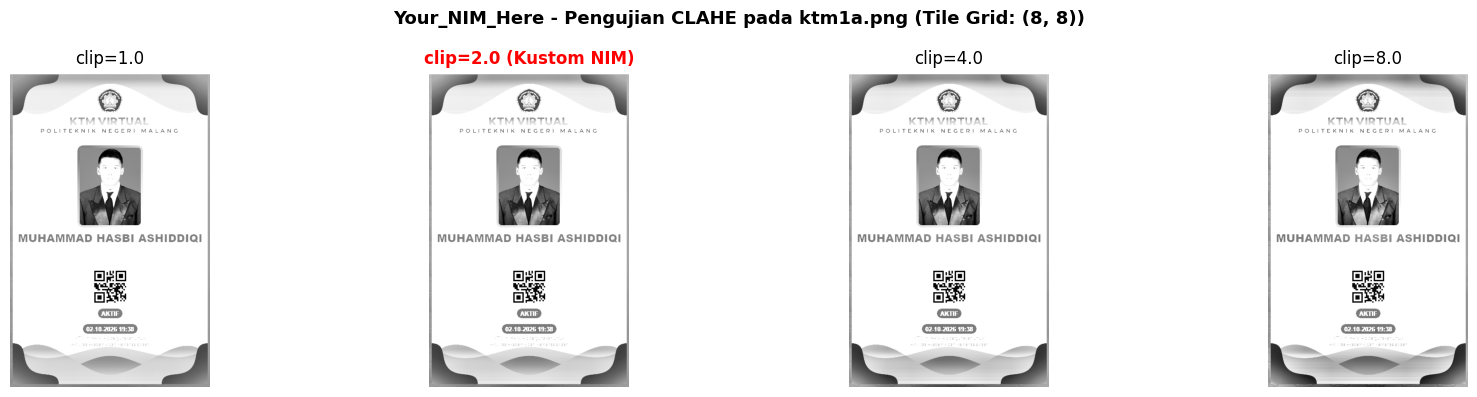

In [30]:
gray_ktm = cv.imread(BASE + '/ktm1a.png', cv.IMREAD_GRAYSCALE)
if 'PARAM' not in globals():
    PARAM = {}
PARAM['clip'] = 2.0
PARAM['tile'] = 8

clip_param = PARAM['clip']
tile_param = (PARAM['tile'], PARAM['tile'])
clips = [1.0, clip_param, 4.0, 8.0]

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    f"{NIM} - Pengujian CLAHE pada ktm1a.png (Tile Grid: {tile_param})",
    fontsize=13,
    fontweight='bold',
)

for idx, c_val in enumerate(clips):
  clahe_obj = cv.createCLAHE(clipLimit=c_val, tileGridSize=tile_param)
  res = clahe_obj.apply(gray_ktm)

  axs[idx].imshow(res, cmap='gray', vmin=0, vmax=255)
  if c_val == clip_param:
    axs[idx].set_title(f'clip={c_val} (Kustom NIM)', color='red', fontweight='bold')
  else:
    axs[idx].set_title(f'clip={c_val}')
  axs[idx].axis('off')

plt.tight_layout()
plt.show()

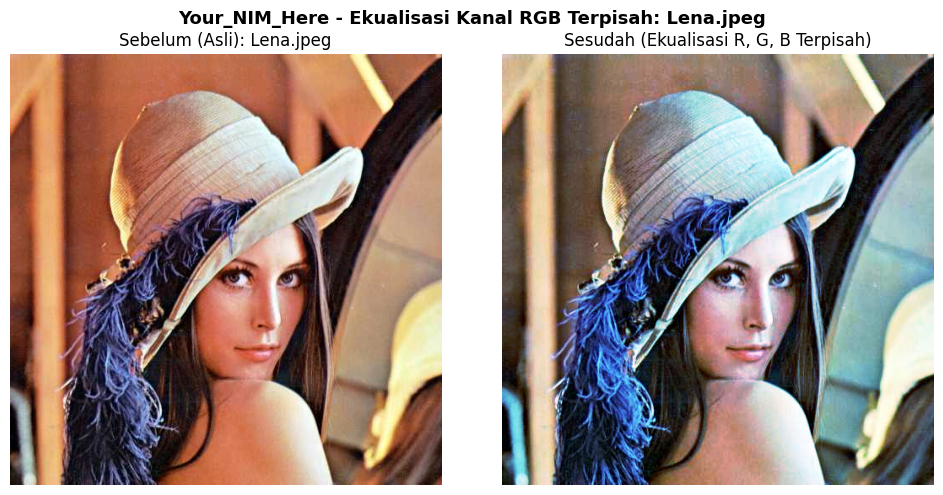

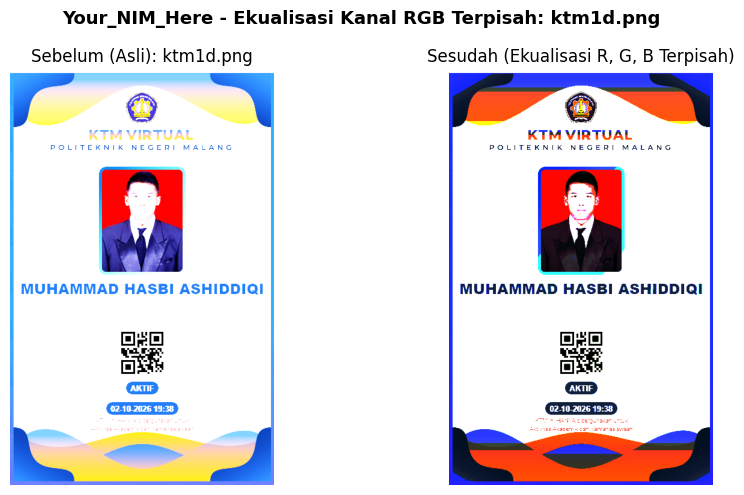

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def ekualisasi_rgb_per_kanal(img_path, nama_citra):
  bgr = cv.imread(img_path)

  if bgr is None:
    print(f'Gagal membaca citra dari: {img_path}')
    return
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb = cv.merge(kanal)
  bgr_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
  he_rgb_rgb = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)


  fig, axs = plt.subplots(1, 2, figsize=(10, 5))
  fig.suptitle(
      f'{NIM} - Ekualisasi Kanal RGB Terpisah: {nama_citra}',
      fontsize=13,
      fontweight='bold',
  )

  axs[0].imshow(bgr_rgb)
  axs[0].set_title(f'Sebelum (Asli): {nama_citra}')
  axs[0].axis('off')

  axs[1].imshow(he_rgb_rgb)
  axs[1].set_title('Sesudah (Ekualisasi R, G, B Terpisah)')
  axs[1].axis('off')

  plt.tight_layout()
  plt.show()


# Tahap 1: Eksekusi untuk lena.jpg
ekualisasi_rgb_per_kanal(CONTOH + '/Lena.jpeg', 'Lena.jpeg')

# Tahap 2: Eksekusi untuk KTM1d.jpg
ekualisasi_rgb_per_kanal(BASE + '/ktm1d.png', 'ktm1d.png')

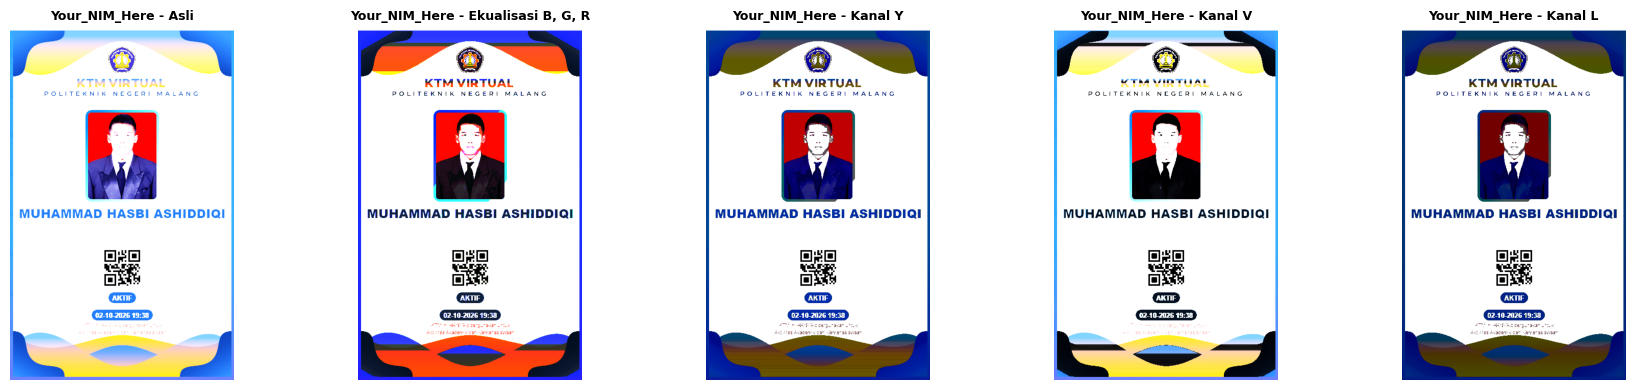

Cara                    geser Hue (der)    rerata terang
----------------------------------------------------------
Asli                               0.00            220.3
Ekualisasi B, G, R                10.00            190.7
Kanal Y                            1.47            185.1
Kanal V                            0.55            206.8
Kanal L                            1.95            181.3


In [32]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

berkas = BASE + '/ktm1d.png'
bgr = cv.imread(berkas)

if bgr is None:
  print(f'Gagal membaca citra dari: {berkas}')
else:
  kanal = list(cv.split(bgr))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb = cv.merge(kanal)
  ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
  hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
  h, sat, v = cv.split(hsv)
  he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
  lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
  l, a, b = cv.split(lab)
  he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
  judul = [
      'Asli',
      'Ekualisasi B, G, R',
      'Kanal Y',
      'Kanal V',
      'Kanal L',
  ]
  citra = [bgr, he_rgb, he_y, he_v, he_l]

  plt.figure(figsize=(18, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - {t}', fontsize=9, fontweight='bold')
    plt.axis('off')
  plt.tight_layout()
  plt.show()
  def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

  print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
  print('-' * 58)
  for t, c in zip(judul, citra):
    hue_shift = geser_hue(bgr, c) * 2
    rerata_terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print('%-22s %16.2f %16.1f' % (t, hue_shift, rerata_terang))

In [ ]:
1. Ekualisasi B, G, R (Cara 1)
2.- Pembulatan Diskret (Quantization Error)
  - Pemotongan Nilai (Clipping / Overflow)
  -
3.- Kanal L (LAB) dirancang agar selaras dengan persepsi visual manusia (perceptually uniform), sehingga peningkatan kontras terlihat lebih natural tanpa menimbulkan kilau (harsh clipping) berlebihan.
  - Kanal V (HSV) cenderung mendorong piksel yang sangat terang menuju warna putih murni (over-saturation/washed out).


In [33]:
import cv2 as cv
import numpy as np

# 1. Ambil Parameter dari NIM
clip_val = PARAM['clip']
tile_val = (PARAM['tile'], PARAM['tile'])

# 2. Baca Citra KTM
bgr = cv.imread(BASE + '/ktm1d.png')

# 3. Metode A: HE Biasa pada Kanal L (LAB)
lab_he = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l1, a1, b1 = cv.split(lab_he)
he_l = cv.cvtColor(
    cv.merge([cv.equalizeHist(l1), a1, b1]), cv.COLOR_LAB2BGR
)

# 4. Metode B: CLAHE pada Kanal L (LAB)
lab_clahe = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l2, a2, b2 = cv.split(lab_clahe)
clahe_obj = cv.createCLAHE(clipLimit=clip_val, tileGridSize=tile_val)
clahe_l = cv.cvtColor(
    cv.merge([clahe_obj.apply(l2), a2, b2]), cv.COLOR_LAB2BGR
)


# Fungsi Ukur Pergeseran Hue
def geser_hue(asli, hasil):
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)
  return d.mean() * 2  # Skala 0-360 derajat


# 5. Cetak Perbandingan Hasil
print(f'=== PERBANDINGAN HE BIASA vs CLAHE (Kanal L) ===')
print(
    f"{'Metode':<20} | {'Geser Hue (Derajat)':<20} | {'Rerata Terang':<15}"
)
print('-' * 60)

hue_he = geser_hue(bgr, he_l)
bright_he = cv.cvtColor(he_l, cv.COLOR_BGR2GRAY).mean()
print(f"{'HE Biasa (Kanal L)':<20} | {hue_he:<20.2f} | {bright_he:<15.2f}")

hue_clahe = geser_hue(bgr, clahe_l)
bright_clahe = cv.cvtColor(clahe_l, cv.COLOR_BGR2GRAY).mean()
print(
    f"{'CLAHE (clip=' + str(clip_val) + ')':<20} | {hue_clahe:<20.2f} |"
    f' {bright_clahe:<15.2f}'
)

=== PERBANDINGAN HE BIASA vs CLAHE (Kanal L) ===
Metode               | Geser Hue (Derajat)  | Rerata Terang  
------------------------------------------------------------
HE Biasa (Kanal L)   | 1.95                 | 181.34         
CLAHE (clip=2.0)     | 0.53                 | 218.00         


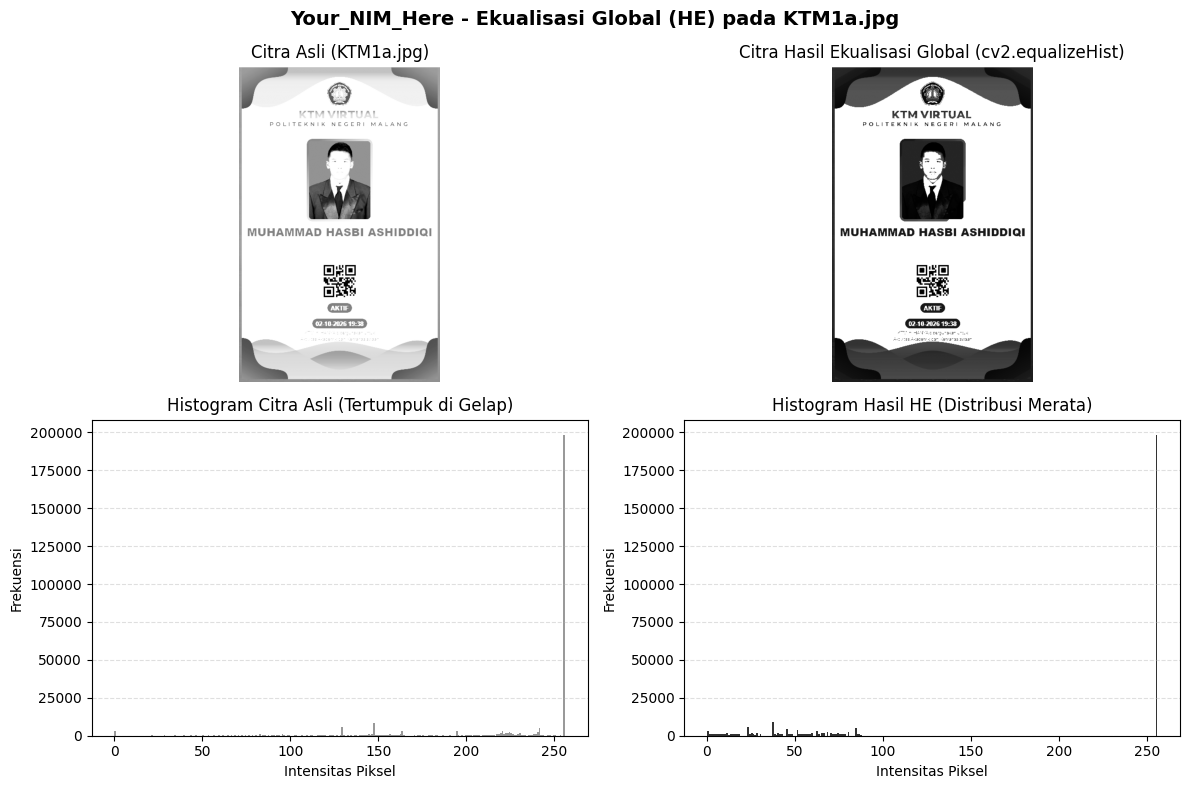

In [34]:
import math
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def histogram_equalization_manual(gray):
  """Fungsi HE manual berbasis Cumulative Distribution Function (CDF)."""
  h, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
  p = h / gray.size
  cdf = np.cumsum(p)
  sk = np.round(cdf * 255).astype(np.uint8)
  return sk[gray]


# Read grayscale KTM1a.jpg
img_path = BASE + '/ktm1a.png'
gray_ktm = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

# Ekualisasi Manual & OpenCV
he_manual = histogram_equalization_manual(gray_ktm)
he_cv = cv.equalizeHist(gray_ktm)

# Visualisasi Layout 2x2
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    f'{NIM} - Ekualisasi Global (HE) pada KTM1a.jpg',
    fontsize=14,
    fontweight='bold',
)

axs[0, 0].imshow(gray_ktm, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title('Citra Asli (KTM1a.jpg)')
axs[0, 0].axis('off')

axs[0, 1].imshow(he_cv, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Citra Hasil Ekualisasi Global (cv2.equalizeHist)')
axs[0, 1].axis('off')

axs[1, 0].hist(
    gray_ktm.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.8
)
axs[1, 0].set_title('Histogram Citra Asli (Tertumpuk di Gelap)')
axs[1, 0].set_xlabel('Intensitas Piksel')
axs[1, 0].set_ylabel('Frekuensi')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.4)

axs[1, 1].hist(
    he_cv.ravel(), bins=256, range=(0, 256), color='black', alpha=0.8
)
axs[1, 1].set_title('Histogram Hasil HE (Distribusi Merata)')
axs[1, 1].set_xlabel('Intensitas Piksel')
axs[1, 1].set_ylabel('Frekuensi')
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [35]:
def hitung_psnr(orig, proc):
  mse = np.mean((orig.astype(float) - proc.astype(float)) ** 2)
  if mse == 0:
    return float('inf')
  return 20 * math.log10(255.0 / math.sqrt(mse))


psnr_val = hitung_psnr(gray_ktm, he_cv)
print(f'Nilai PSNR (ktm1a.png vs Hasil HE) : {psnr_val:.2f} dB')

Nilai PSNR (ktm1a.png vs Hasil HE) : 10.61 dB


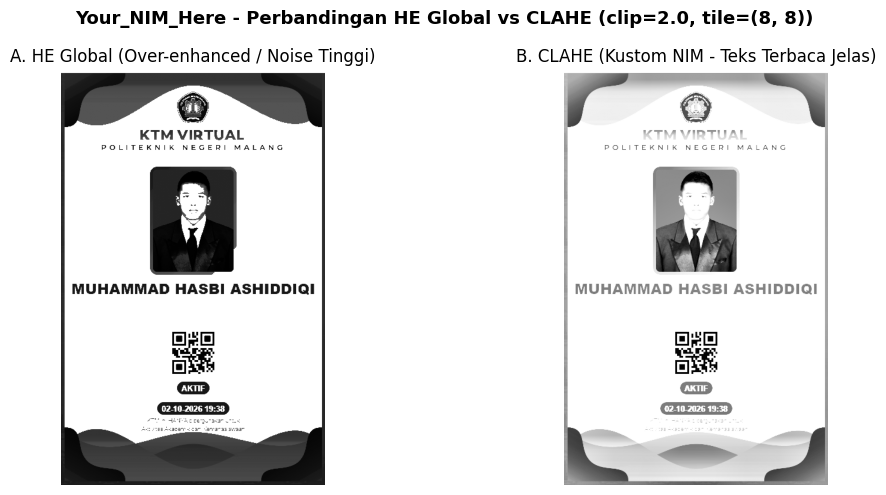

In [36]:
# Ambil Parameter NIM
clip_param = PARAM['clip']
tile_param = (PARAM['tile'], PARAM['tile'])

# 1. CLAHE dengan parameter NIM
clahe_nim = cv.createCLAHE(clipLimit=clip_param, tileGridSize=tile_param)
img_clahe = clahe_nim.apply(gray_ktm)

# Visualisasi Komparasi HE Global vs CLAHE
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"{NIM} - Perbandingan HE Global vs CLAHE (clip={clip_param}, tile={tile_param})",
    fontsize=13,
    fontweight='bold',
)

axs[0].imshow(he_cv, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('A. HE Global (Over-enhanced / Noise Tinggi)')
axs[0].axis('off')

axs[1].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axs[1].set_title('B. CLAHE (Kustom NIM - Teks Terbaca Jelas)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

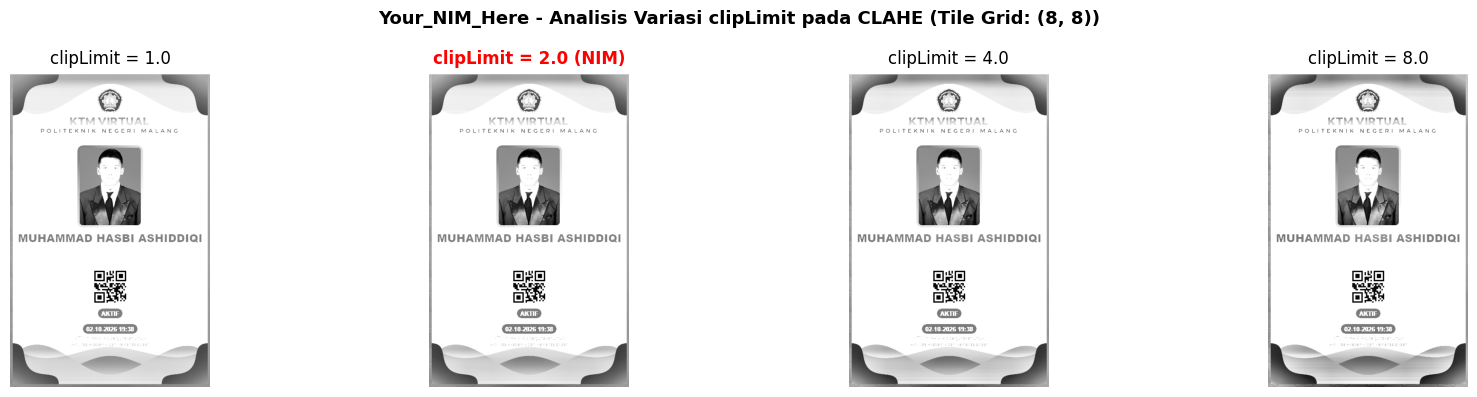

In [37]:
# Uji 4 variasi clipLimit (misal: 1.0, nilainim, 4.0, 8.0)
clips = [1.0, clip_param, 4.0, 8.0]

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    f"{NIM} - Analisis Variasi clipLimit pada CLAHE (Tile Grid: {tile_param})",
    fontsize=13,
    fontweight='bold',
)

for idx, c_val in enumerate(clips):
  c_obj = cv.createCLAHE(clipLimit=c_val, tileGridSize=tile_param)
  res_img = c_obj.apply(gray_ktm)

  axs[idx].imshow(res_img, cmap='gray', vmin=0, vmax=255)
  if c_val == clip_param:
    axs[idx].set_title(
        f'clipLimit = {c_val} (NIM)', color='red', fontweight='bold'
    )
  else:
    axs[idx].set_title(f'clipLimit = {c_val}')
  axs[idx].axis('off')

plt.tight_layout()
plt.show()

In [39]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def floyd_steinberg_dithering(img, levels=2):
  """Melakukan Floyd-Steinberg Dithering pada citra grayscale maupun RGB."""

  img_float = img.astype(np.float32)
  h, w = img_float.shape[:2]

  step = 255.0 / (levels - 1)

  for y in range(h):
    for x in range(w):
      old_val = img_float[y, x].copy()
      # Kuantisasi ke nilai terdekat
      new_val = np.round(old_val / step) * step
      img_float[y, x] = new_val

      # Hitung error kuantisasi
      err = old_val - new_val

      # Distribusi error ke tetangga (jika dalam batas citra)
      if x + 1 < w:
        img_float[y, x + 1] += err * (7 / 16)
      if y + 1 < h and x - 1 >= 0:
        img_float[y + 1, x - 1] += err * (3 / 16)
      if y + 1 < h:
        img_float[y + 1, x] += err * (5 / 16)
      if y + 1 < h and x + 1 < w:
        img_float[y + 1, x + 1] += err * (1 / 16)

  # Potong nilai ke rentang valid [0, 255] dan konversi kembali ke uint8
  return np.clip(img_float, 0, 255).astype(np.uint8)

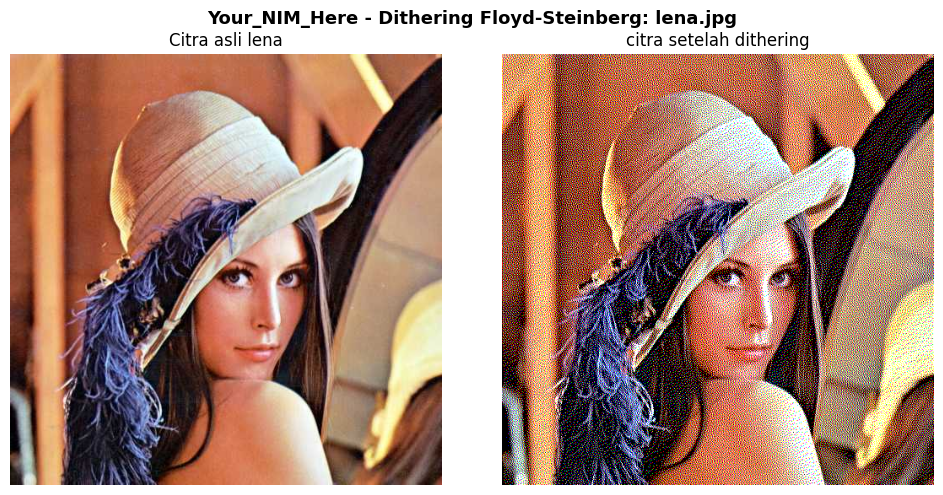

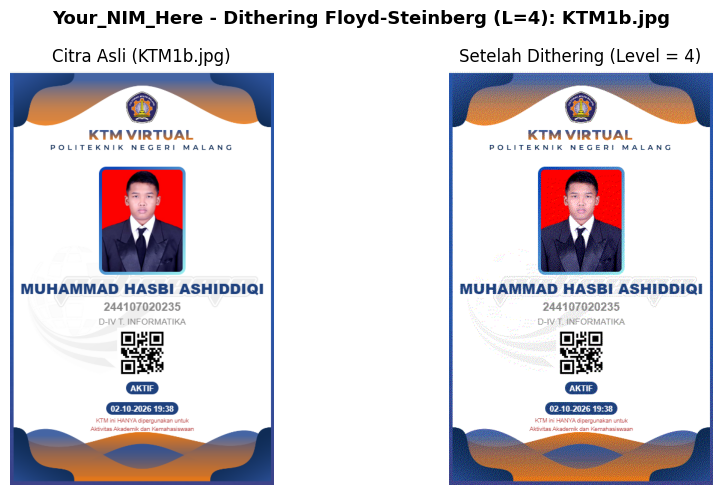

In [44]:
# --- Tahap 1: lena.jpg (Default 2 level per kanal) ---
img_lena = cv.imread(CONTOH + '/Lena.jpeg')
dither_lena = floyd_steinberg_dithering(img_lena, levels=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(
    f'{NIM} - Dithering Floyd-Steinberg: lena.jpg',
    fontsize=13,
    fontweight='bold',
)

axs[0].imshow(cv.cvtColor(img_lena, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra asli lena')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(dither_lena, cv.COLOR_BGR2RGB))
axs[1].set_title('citra setelah dithering')
axs[1].axis('off')

plt.tight_layout()
plt.show()

# --- Tahap 2: KTM1b.jpg (Dengan PARAM['L']) ---
# Ensure PARAM has 'L' key defined
if 'PARAM' not in globals():
    PARAM = {}
PARAM['L'] = 4 # Default value for levels in dithering
level_L = PARAM['L']
img_ktm1b = cv.imread(BASE + '/ktm1b.png')
dither_ktm1b = floyd_steinberg_dithering(img_ktm1b, levels=level_L)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(
    f"{NIM} - Dithering Floyd-Steinberg (L={level_L}): KTM1b.jpg",
    fontsize=13,
    fontweight='bold',
)

axs[0].imshow(cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra Asli (KTM1b.jpg)')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(dither_ktm1b, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Setelah Dithering (Level = {level_L})')
axs[1].axis('off')

plt.tight_layout()
plt.show()

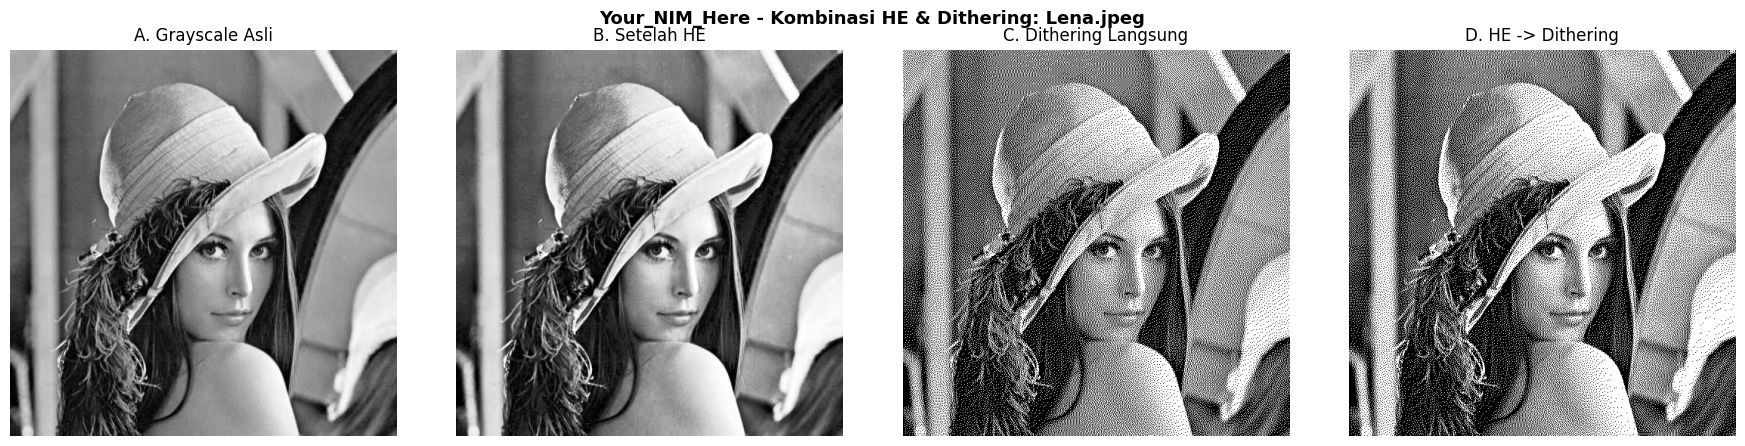

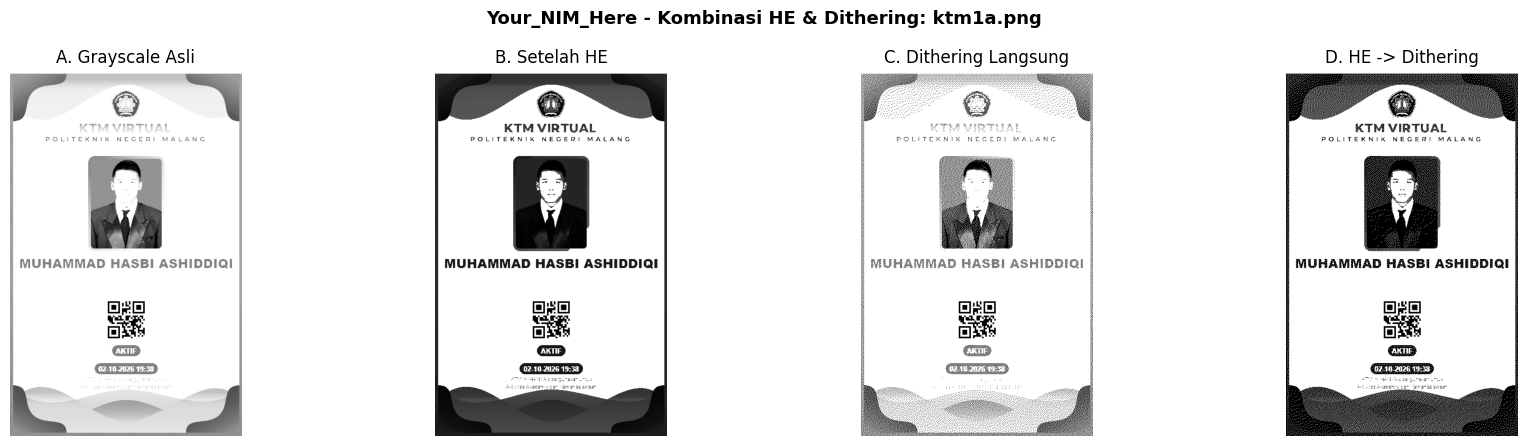

In [43]:
def proses_soal_2(img_path, nama_citra):
  # 1. Baca sebagai grayscale
  gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

  # 2. Ekualisasi Histogram terlebih dahulu
  gray_eq = cv.equalizeHist(gray)

  # 3. Dithering tanpa ekualisasi
  dither_direct = floyd_steinberg_dithering(gray, levels=2)

  # 4. Dithering setelah ekualisasi
  dither_after_eq = floyd_steinberg_dithering(gray_eq, levels=2)

  # Visualisasi 4 Tahapan
  fig, axs = plt.subplots(1, 4, figsize=(18, 4.5))
  fig.suptitle(
      f'{NIM} - Kombinasi HE & Dithering: {nama_citra}',
      fontsize=13,
      fontweight='bold',
  )

  axs[0].imshow(gray, cmap='gray')
  axs[0].set_title('A. Grayscale Asli')
  axs[0].axis('off')

  axs[1].imshow(gray_eq, cmap='gray')
  axs[1].set_title('B. Setelah HE')
  axs[1].axis('off')

  axs[2].imshow(dither_direct, cmap='gray')
  axs[2].set_title('C. Dithering Langsung')
  axs[2].axis('off')

  axs[3].imshow(dither_after_eq, cmap='gray')
  axs[3].set_title('D. HE -> Dithering')
  axs[3].axis('off')

  plt.tight_layout()
  plt.show()


# Eksekusi untuk lena_lc.jpg (Uji Coba)
proses_soal_2(CONTOH + '/Lena.jpeg', 'Lena.jpeg')

# Eksekusi untuk KTM1a.jpg (Citra KTM)
proses_soal_2(BASE + '/ktm1a.png', 'ktm1a.png')